In [21]:
import numpy as np
import pandas as pd
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean
import matplotlib.pyplot as plt
from scipy.stats import zscore


In [22]:
def euclidean_scalar(a, b):
    return abs(a - b)

In [23]:
firma_1 = pd.read_csv("firma_1.csv")
firma_2 = pd.read_csv("firma_3.csv")

firma_1['vx_norm'] = (firma_1['vx'] - firma_1['vx'].min()) / (firma_1['vx'].max() - firma_1['vx'].min())
firma_2['vx_norm'] = (firma_2['vx'] - firma_2['vx'].min()) / (firma_2['vx'].max() - firma_2['vx'].min())
firma_1['vy_norm'] = (firma_1['vy'] - firma_1['vy'].min()) / (firma_1['vy'].max() - firma_1['vy'].min())
firma_2['vy_norm'] = (firma_2['vy'] - firma_2['vy'].min()) / (firma_2['vy'].max() - firma_2['vy'].min())

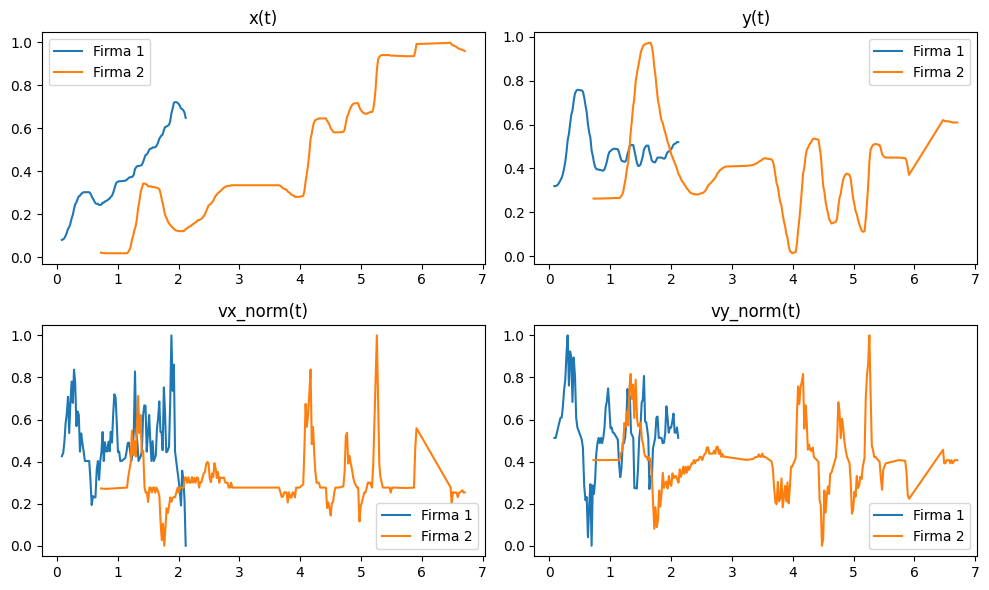

In [24]:
fig, axs = plt.subplots(2, 2, figsize=(10, 6))
componentes = ['x', 'y', 'vx_norm', 'vy_norm']
for i, comp in enumerate(componentes):
    ax = axs[i // 2, i % 2]
    ax.plot(firma_1['t'][1:], firma_1[comp][1:], label='Firma 1')
    ax.plot(firma_2['t'][1:], firma_2[comp][1:], label='Firma 2')
    ax.set_title(f'{comp}(t)')
    ax.legend()
plt.tight_layout()
plt.show()


In [25]:
distancias = {}
for comp in componentes:
    serie1 = firma_1[comp].dropna().astype(float).values.flatten().tolist()[1:]  # OMITIMOS el primer punto
    serie2 = firma_2[comp].dropna().astype(float).values.flatten().tolist()[1:]

    if len(serie1) == 0 or len(serie2) == 0:
        print(f"⚠️ Serie vacía tras omitir primer punto: {comp}.")
        continue

    # Verificamos tipo del primer elemento (nuevo primero)
    print(f"{comp} → tipo serie1[0]: {type(serie1[0])}, valor: {serie1[0]}")

    # Validamos que sean escalares simples
    if isinstance(serie1[0], (list, tuple)) or isinstance(serie2[0], (list, tuple)):
        print(f"⚠️ Serie malformada: {comp}")
        continue

    # Calculamos DTW
    distancia, _ = fastdtw(serie1, serie2, dist=euclidean_scalar)
    distancias[comp] = distancia

print("\n✅ Distancias DTW finales:")
print(distancias)


x → tipo serie1[0]: <class 'float'>, valor: 0.0806277056277056
y → tipo serie1[0]: <class 'float'>, valor: 0.3198051948051948
vx_norm → tipo serie1[0]: <class 'float'>, valor: 0.42567328575828545
vy_norm → tipo serie1[0]: <class 'float'>, valor: 0.5127174368237817

✅ Distancias DTW finales:
{'x': np.float64(13.354978354978352), 'y': np.float64(20.04058441558442), 'vx_norm': np.float64(20.53509437033922), 'vy_norm': np.float64(14.795719941114413)}


In [26]:
print(distancias.values())
dtw_total = sum(distancias.values())
print(f"Distancia total DTW: {dtw_total:.2f}")

# Puedes ajustar este umbral empíricamente con tus propias firmas
umbral = 30  

if dtw_total < umbral:
    print("✅ La firma parece auténtica (dentro del umbral).")
else:
    print("❌ La firma no coincide suficientemente.")


dict_values([np.float64(13.354978354978352), np.float64(20.04058441558442), np.float64(20.53509437033922), np.float64(14.795719941114413)])
Distancia total DTW: 68.73
❌ La firma no coincide suficientemente.


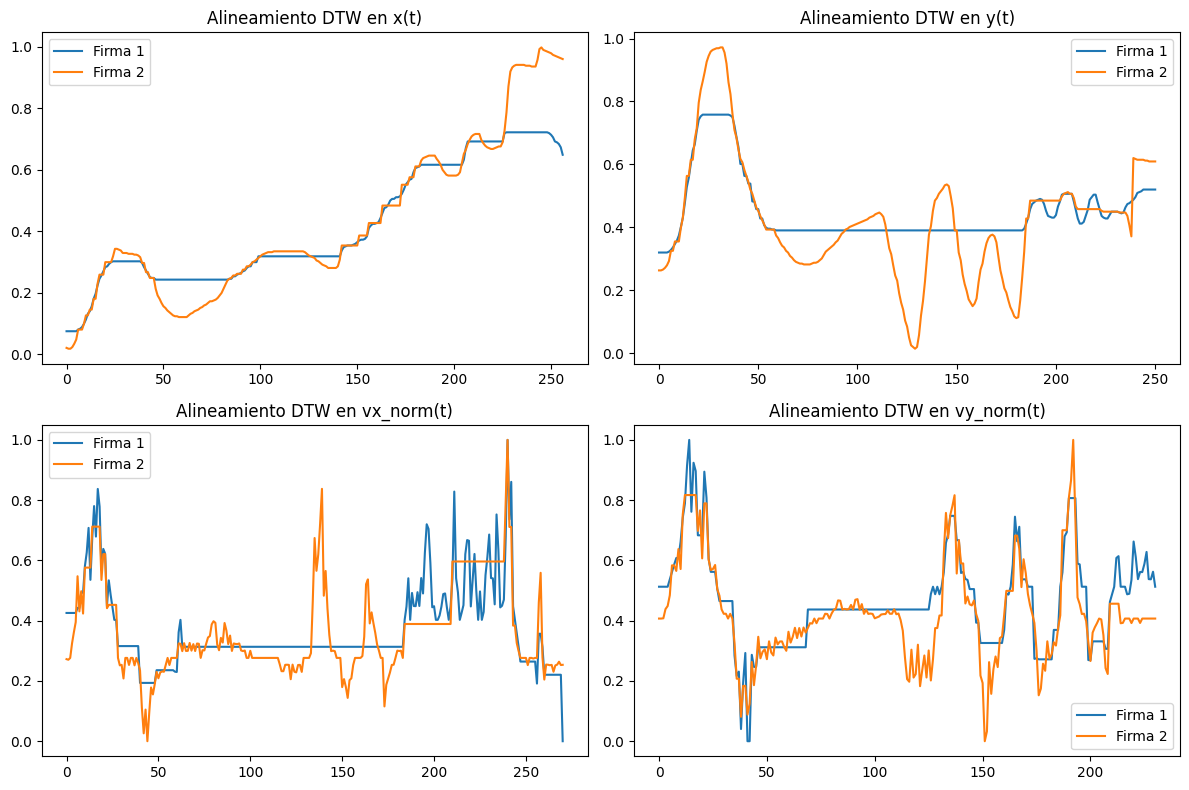

c:\Users\fabio\Desktop\Nueva\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


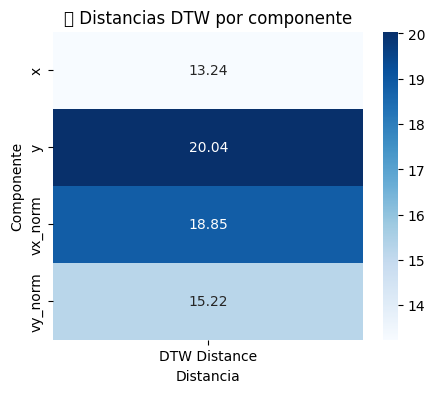

In [27]:
from fastdtw import fastdtw
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Función escalar para DTW (porque trabajamos con valores 1D)
def euclidean_scalar(a, b):
    return abs(a - b)

# Componentes a comparar
componentes = ['x', 'y', 'vx_norm', 'vy_norm']

# Inicializar matriz de distancias
distancias = {}

# Graficar cada alineamiento
plt.figure(figsize=(12, 8))
for idx, comp in enumerate(componentes, 1):
    serie1 = firma_1[comp].dropna().astype(float).tolist()
    serie2 = firma_2[comp].dropna().astype(float).tolist()

    if not serie1 or not serie2:
        print(f"⚠️ Serie vacía: {comp}")
        continue

    distancia, path = fastdtw(serie1, serie2, dist=euclidean_scalar)

    # Guardar distancia
    distancias[comp] = distancia

    # Alineamiento para graficar
    serie1_al = [serie1[i] for i, _ in path]
    serie2_al = [serie2[j] for _, j in path]

    plt.subplot(2, 2, idx)
    plt.plot(serie1_al[1:], label='Firma 1')
    plt.plot(serie2_al[1:], label='Firma 2')
    plt.title(f'Alineamiento DTW en {comp}(t)')
    plt.legend()

plt.tight_layout()
plt.show()

# Crear DataFrame de matriz de distancias
matriz = pd.DataFrame(distancias, index=["DTW Distance"]).T

# Mostrar matriz como heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(matriz, annot=True, cmap="Blues", fmt=".2f", cbar=True)
plt.title("📏 Distancias DTW por componente")
plt.ylabel("Componente")
plt.xlabel("Distancia")
plt.show()


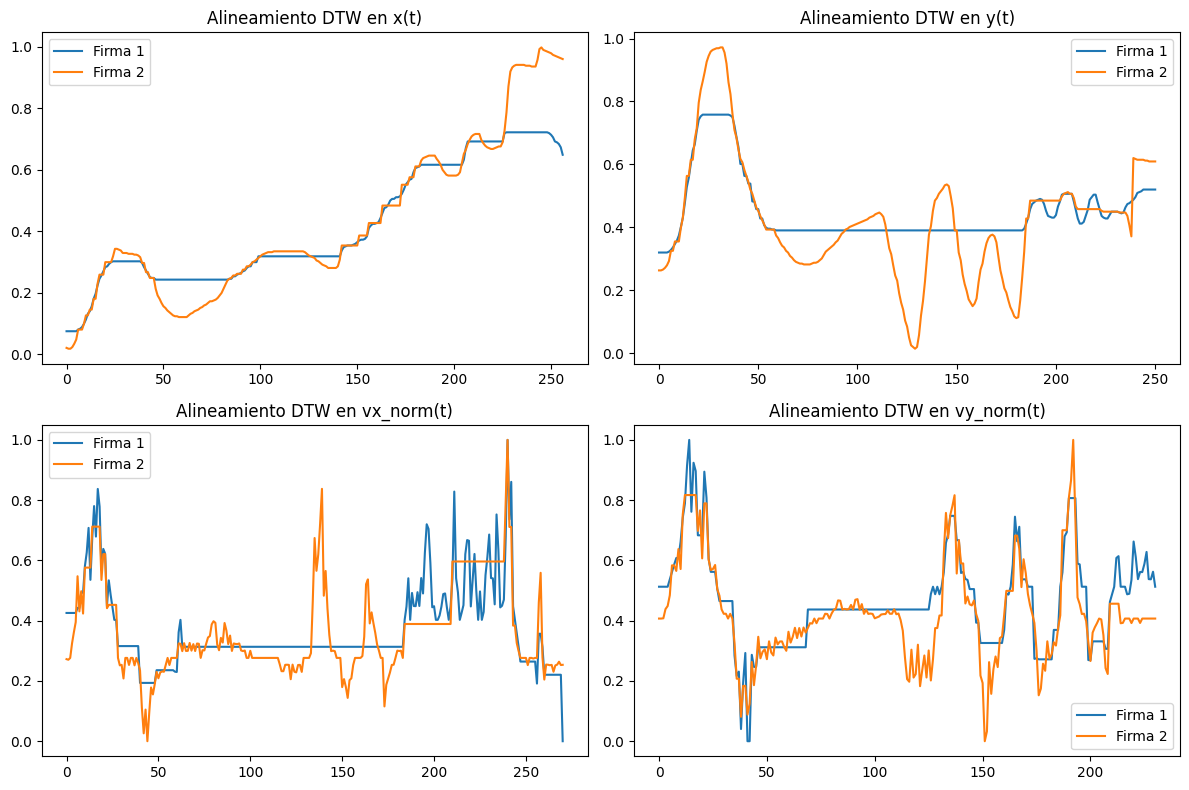

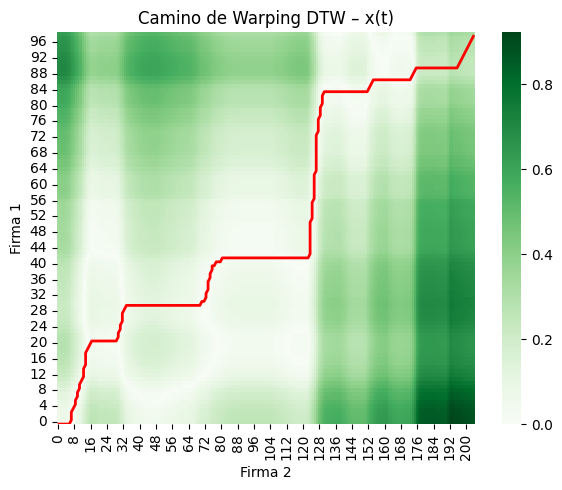

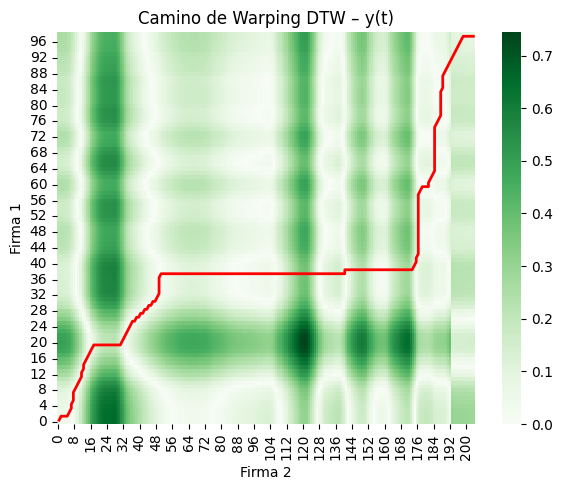

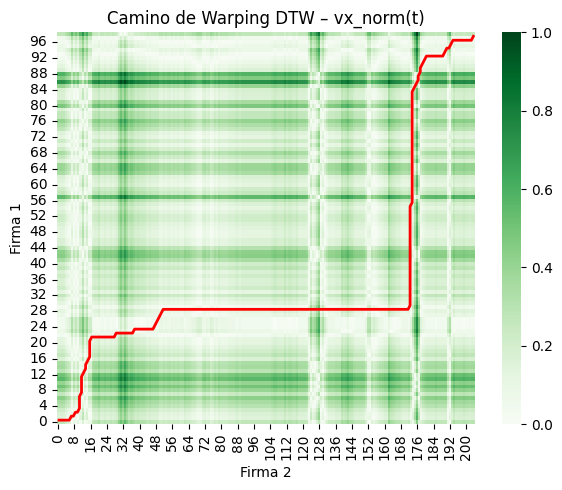

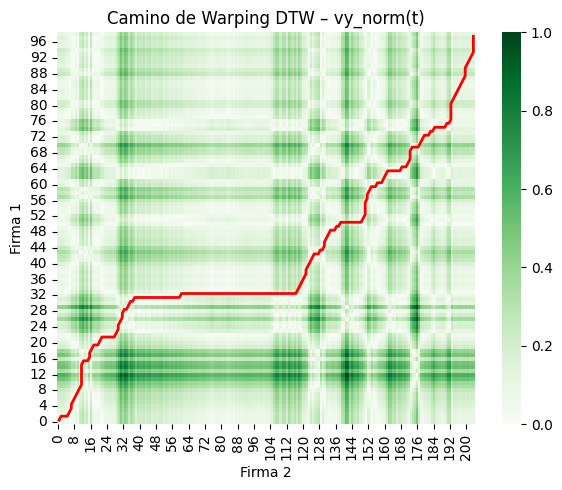

c:\Users\fabio\Desktop\Nueva\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


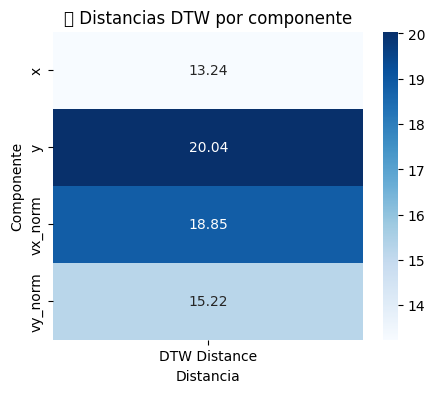

In [28]:
from fastdtw import fastdtw
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Función escalar para DTW
def euclidean_scalar(a, b):
    return abs(a - b)

componentes = ['x', 'y', 'vx_norm', 'vy_norm']
distancias = {}

plt.figure(figsize=(12, 8))
for idx, comp in enumerate(componentes, 1):
    serie1 = firma_1[comp].dropna().astype(float).tolist()
    serie2 = firma_2[comp].dropna().astype(float).tolist()

    if not serie1 or not serie2:
        print(f"⚠️ Serie vacía: {comp}")
        continue

    distancia, path = fastdtw(serie1, serie2, dist=euclidean_scalar)
    distancias[comp] = distancia

    # Alineamiento para graficar series
    serie1_al = [serie1[i] for i, _ in path]
    serie2_al = [serie2[j] for _, j in path]

    plt.subplot(2, 2, idx)
    plt.plot(serie1_al[1:], label='Firma 1')
    plt.plot(serie2_al[1:], label='Firma 2')
    plt.title(f'Alineamiento DTW en {comp}(t)')
    plt.legend()

plt.tight_layout()
plt.show()

# 🎯 Gráfico del path sobre la matriz de distancia
for comp in componentes:
    serie1 = firma_1[comp].dropna().astype(float).tolist()
    serie2 = firma_2[comp].dropna().astype(float).tolist()

    if not serie1 or not serie2:
        continue

    distancia, path = fastdtw(serie1, serie2, dist=euclidean_scalar)

    # Crear matriz de distancias locales
    dist_matrix = np.zeros((len(serie1), len(serie2)))
    for i in range(len(serie1)):
        for j in range(len(serie2)):
            dist_matrix[i, j] = euclidean_scalar(serie1[i], serie2[j])

    # Graficar
    plt.figure(figsize=(6, 5))
    sns.heatmap(dist_matrix, cmap="Greens", cbar=True)
    path_x, path_y = zip(*path)
    plt.plot(path_y[1:], path_x[1:], color='red', linewidth=2)  # path sobre matriz
    plt.title(f'Camino de Warping DTW – {comp}(t)')
    plt.xlabel("Firma 2")
    plt.ylabel("Firma 1")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

# Mostrar heatmap resumen de distancias
matriz = pd.DataFrame(distancias, index=["DTW Distance"]).T

plt.figure(figsize=(5, 4))
sns.heatmap(matriz, annot=True, cmap="Blues", fmt=".2f", cbar=True)
plt.title("📏 Distancias DTW por componente")
plt.ylabel("Componente")
plt.xlabel("Distancia")
plt.show()
